# 2D Representation of MNIST using PCA

We use the MNIST handwritten digit dataset containing 28×28 grayscale images.
Each image is represented as a 784-dimensional vector, with pixel values
normalized to the range [0, 1].

PCA is applied to the training data, and the first two principal components
are used to obtain a 2D representation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA

## Load the MNIST Dataset

The MNIST files are stored in IDX format. The image files contain the 28 × 28 grayscale images, while the label files contain the corresponding digit labels.

In [2]:
# Path to MNIST dataset
DATA_DIR = Path("data/mnist")

train_images_path = DATA_DIR / "train-images.idx3-ubyte"
train_labels_path = DATA_DIR / "train-labels.idx1-ubyte"

test_images_path = DATA_DIR / "t10k-images.idx3-ubyte"
test_labels_path = DATA_DIR / "t10k-labels.idx1-ubyte"

print(train_images_path)
print(test_images_path)

data\mnist\train-images.idx3-ubyte
data\mnist\t10k-images.idx3-ubyte


In [3]:
def load_mnist_images(path):
    """Load MNIST images from an IDX3-UBYTE file."""
    with open(path, "rb") as f:
        magic = int.from_bytes(f.read(4), byteorder="big")
        n_images = int.from_bytes(f.read(4), byteorder="big")
        n_rows = int.from_bytes(f.read(4), byteorder="big")
        n_cols = int.from_bytes(f.read(4), byteorder="big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    images = data.reshape(n_images, n_rows * n_cols)
    return images

def load_mnist_labels(path):
    """Load MNIST labels from an IDX1-UBYTE file."""
    with open(path, "rb") as f:
        magic = int.from_bytes(f.read(4), byteorder="big")
        n_labels = int.from_bytes(f.read(4), byteorder="big")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [4]:
# Load training data
X_train = load_mnist_images(train_images_path)
y_train = load_mnist_labels(train_labels_path)

# Load test data
X_test = load_mnist_images(test_images_path)
y_test = load_mnist_labels(test_labels_path)

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 784)
Training labels: (60000,)
Test images: (10000, 784)
Test labels: (10000,)


## Normalize Pixel Values

The original MNIST pixel values range from 0 to 255. We normalize them
to the range [0, 1].

In [5]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Apply PCA

PCA is fitted on the MNIST training data using the first two principal components.

In [6]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

print("Training PCA representation:", X_train_pca.shape)

Training PCA representation: (60000, 2)


In [7]:
explained_variance = pca.explained_variance_ratio_

pc1_variance = explained_variance[0]
pc2_variance = explained_variance[1]
cumulative_variance = explained_variance.sum()

print(f"PC1 variance explained: {pc1_variance:.4f} ({pc1_variance * 100:.2f}%)")
print(f"PC2 variance explained: {pc2_variance:.4f} ({pc2_variance * 100:.2f}%)")
print(f"Cumulative variance: {cumulative_variance:.4f} ({cumulative_variance * 100:.2f}%)")

PC1 variance explained: 0.0970 (9.70%)
PC2 variance explained: 0.0710 (7.10%)
Cumulative variance: 0.1680 (16.80%)


## Project Test Images onto the PCA Space

The PCA model fitted on the training data is used to transform the test
images into the same two-dimensional PCA space.

In [8]:
X_test_pca = pca.transform(X_test)

print("Test PCA representation:", X_test_pca.shape)

Test PCA representation: (10000, 2)


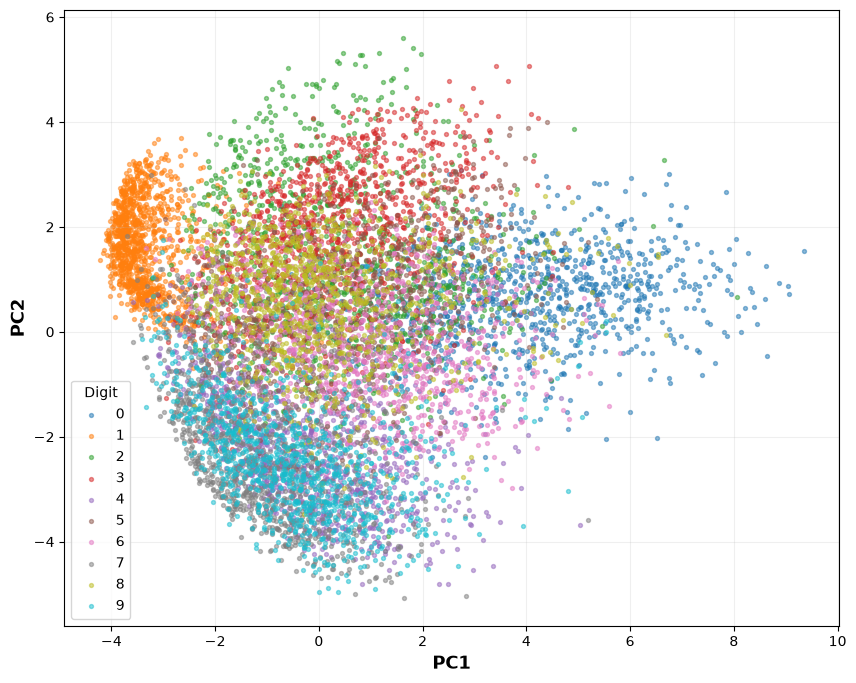

In [9]:
plt.figure(figsize=(10, 8))

for digit in range(10):
    mask = y_test == digit
    plt.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1], s=8, alpha=0.5, label=str(digit))
plt.xlabel("PC1", fontsize=13, fontweight="bold")
plt.ylabel("PC2", fontsize=13, fontweight="bold")
plt.legend(title="Digit")
plt.grid(alpha=0.2)
plt.show()

## Selected Samples from Each Digit Class

Five test samples are randomly selected from each digit class and represented in the two-dimensional PCA space.

In [10]:
np.random.seed(11009)

samples_per_class = 5
selected_indices = []

for digit in range(10):
    indices = np.where(y_test == digit)[0]
    selected = np.random.choice(indices, size=samples_per_class, replace=False)
    selected_indices.extend(selected)
selected_indices = np.array(selected_indices)
X_selected = X_test[selected_indices]
y_selected = y_test[selected_indices]
X_selected_pca = X_test_pca[selected_indices]
print("Selected samples:", len(selected_indices))

Selected samples: 50


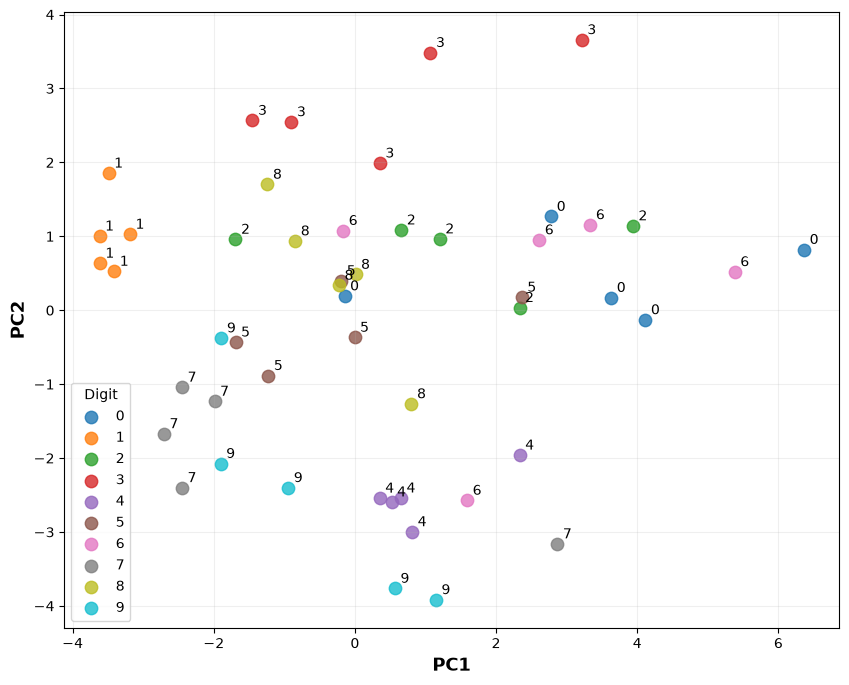

In [11]:
plt.figure(figsize=(10, 8))

for digit in range(10):
    mask = y_selected == digit
    plt.scatter(X_selected_pca[mask, 0], X_selected_pca[mask, 1], s=80, alpha=0.8, label=str(digit))
    for x, y_coord in X_selected_pca[mask]:
        plt.annotate(str(digit), (x, y_coord), xytext=(4, 4), textcoords="offset points")
plt.xlabel("PC1", fontsize=13, fontweight="bold")
plt.ylabel("PC2", fontsize=13, fontweight="bold")
plt.legend(title="Digit")
plt.grid(alpha=0.2)
plt.show()

### Observations

The PCA projection shows that some digit classes form relatively distinct groups, whereas several classes overlap. Digits with similar visual structures tend to occur closer together in the PCA space. Since only two principal components are retained from the original 784 dimensions, considerable information is lost, resulting in overlap between some classes.

## Reconstruction Using the First Two Principal Components

The selected test images are projected onto PC1 and PC2 and then reconstructed back into the original 784-dimensional space.

In [12]:
X_selected_pca = pca.transform(X_selected)
X_selected_reconstructed = pca.inverse_transform(X_selected_pca)
X_selected_reconstructed = np.clip(X_selected_reconstructed, 0, 1)

print("Original shape:", X_selected.shape)
print("Reconstructed shape:", X_selected_reconstructed.shape)

Original shape: (50, 784)
Reconstructed shape: (50, 784)


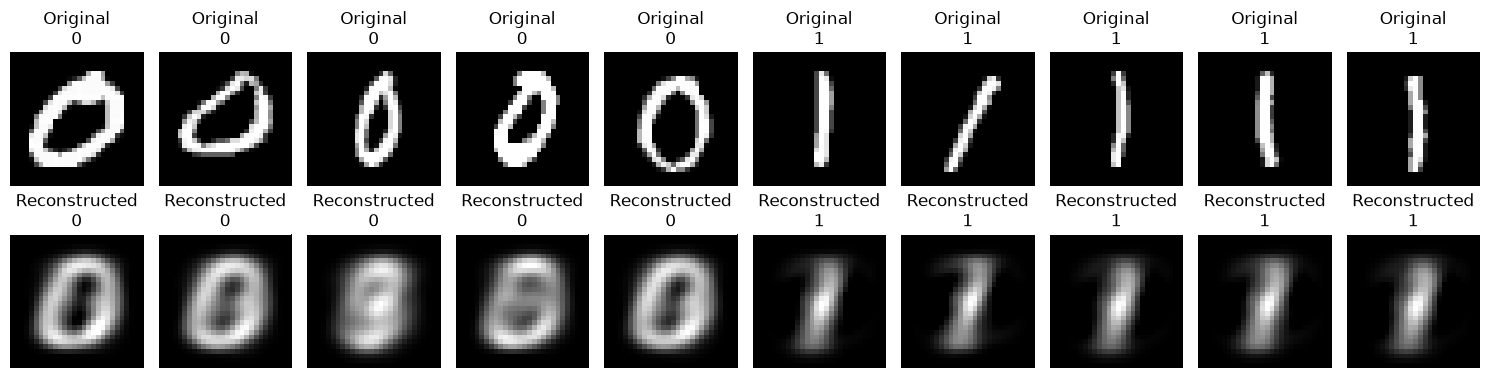

In [13]:
n_samples = 10
fig, axes = plt.subplots(2, n_samples, figsize=(15, 4))
for i in range(n_samples):
    axes[0, i].imshow(X_selected[i].reshape(28, 28),cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Original\n{y_selected[i]}")
    axes[1, i].imshow(X_selected_reconstructed[i].reshape(28, 28),cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Reconstructed\n{y_selected[i]}")
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("PCA", fontsize=12)

plt.tight_layout()
plt.show()

### Reconstruction Discussion

The reconstructed images preserve the general shape and identity of the digits but lose fine-grained details. This occurs because the original 784-dimensional images are represented using only two principal components. The first two components capture the directions of maximum variance, but cannot preserve all the information present in the original images.

In [14]:
from sklearn.metrics import mean_squared_error

reconstruction_error = mean_squared_error(X_selected, X_selected_reconstructed)
print(f"Mean Squared Reconstruction Error: {reconstruction_error:.3f}")

Mean Squared Reconstruction Error: 0.057


## (c) Analysis and Interpretation

### (i) Class Separation and Overlap

The 2D PCA representation shows that some digit classes are relatively well separated, while others exhibit significant overlap. Digits with distinct shapes tend to form more compact and separated regions, whereas visually similar digits can appear close to one another. For example, digits such as 0 and 1 tend to be relatively distinguishable, while classes such as 3, 5, and 8 may show greater overlap. This overlap occurs because PCA is unsupervised and finds directions of maximum overall variance rather than directions that specifically maximize class separation. Additionally, different digits can have similar shapes, strokes, and writing styles.

### (ii) Usefulness of the First Two Principal Components

Although PC1 and PC2 may not capture most of the total variance, they are still useful for visualization because they provide a low-dimensional representation that preserves the directions of greatest variance in the dataset. Plotting these two components allows the overall structure, clustering tendencies, and relationships between different digit classes to be observed in two dimensions. Thus, PCA provides an interpretable visual summary of the high-dimensional MNIST data even when substantial information is represented by the remaining principal components.

### (iii) Information Lost During Dimensionality Reduction

Reducing the original 784-dimensional representation to only two dimensions results in the loss of information contained in the remaining principal components. The explained-variance ratio of PC1 and PC2 quantifies the fraction of the total variance retained by the 2D representation, while the remaining variance corresponds to information discarded during dimensionality reduction. This loss can also be observed in the reconstructed images: the reconstructed digits preserve their general shape and identity but lose fine details and subtle variations present in the original images. Therefore, the reconstruction results demonstrate that two principal components are useful for capturing the overall structure of MNIST images, but are insufficient to preserve the complete information contained in the original 784-dimensional representation.